In [1]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, log_loss,
    silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_mutual_info_score, adjusted_rand_score,
    mean_absolute_error, mean_squared_log_error, median_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
)
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [2]:
# CLASSIFICATION

In [3]:
'''
Accuracy score is the ratio of correctly predicted observations to the total observations. It is a common metric for classification problems, especially when the classes are balanced. 
The formula for accuracy is: 
    (TP + TN) / (TP + TN + FP + FN)

Best For: Classification problems with balanced classes.
Worse for: Imbalanced datasets, as it may give a misleading impression of model performance.
'''

y_true = [1,0,1,1,0]
y_pred = [1,0,0,1,0]
acc = accuracy_score(y_true, y_pred)
print(acc)

0.8


In [4]:
'''
Precision score: Precision is the ratio of correctly predicted positive observations to the total predicted positives. It is a useful metric when the cost of false positives is high.
The formula for precision is:
    TP / (TP + FP)

Best For: Classification problems where the cost of false positives is high.
Worse for: Imbalanced datasets, as it may not reflect the true performance of the model.
'''
y_true = [1,0,1,1,0]
y_pred = [1,0,0,1,0]
precision = precision_score(y_true,y_pred)
print(precision)

1.0


In [5]:
'''
Recall score: Recall is the ratio of correctly predicted positive observations to the all observations in actual class. 
    It is a useful metric when the cost of false negatives is high.
The formula for recall is:
    TP / (TP + FN)

Best For: Classification problems where the cost of false negatives is high.
Worse for: Imbalanced datasets, as it may not reflect the true performance of the model.
'''
recall = recall_score(y_true,y_pred)
print(recall)

0.6666666666666666


In [6]:
'''
f1_score: F1 Score is the weighted average of Precision and Recall. 
    It is a useful metric when you need to balance precision and recall, especially in cases of imbalanced datasets.
The formula for F1 Score is:
    2 * (Precision * Recall) / (Precision + Recall)

Best For: Classification problems with imbalanced datasets, where you want to balance precision and recall.
Worse for: Situations where either precision or recall is more important than the other, 
    as it may not reflect the true performance of the model.
'''
f1 = f1_score(y_true,y_pred)
print(f1)

0.8


In [7]:
'''
Confusion Matrix: A confusion matrix is a table that is used to evaluate the performance of a classification model. 
    It shows the true positives, true negatives, false positives, and false negatives.
|          | Pred 0 | Pred 1 |
| -------- | ------ | ------ |
| Actual 0 | TN     | FP     |
| Actual 1 | FN     | TP     |

Best For: Classification problems, as it provides a comprehensive view of the model's performance.
Worse for: Large datasets, as the confusion matrix can become difficult to interpret.
'''
cm = confusion_matrix(y_true,y_pred)
print(cm)

[[2 0]
 [1 2]]


In [8]:
'''
Classification Report: A classification report is a summary of the precision, recall, f1-score, 
    and support for each class in a classification problem.
Best For: Classification problems, as it provides a comprehensive view of the model's performance.
Worse for: Large datasets, as the report can become difficult to interpret.
'''
print(
    classification_report(
        y_true,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      0.67      0.80         3

    accuracy                           0.80         5
   macro avg       0.83      0.83      0.80         5
weighted avg       0.87      0.80      0.80         5



In [9]:
'''
Roc AUC Score: The ROC AUC score is a metric that evaluates the performance of a binary classification model. 
    It is the area under the receiver operating characteristic (ROC) curve, 
    which plots the true positive rate against the false positive rate at various threshold settings.
Best For: Binary classification problems, especially when the classes are imbalanced.   
Worse for: Multiclass classification problems, as it may not provide a clear interpretation of model performance.
'''
y_true = [0,1,1,0]
y_prob = [
    0.1,
    0.8,
    0.3,
    0.3
]
auc = roc_auc_score(y_true, y_prob)
print(auc)

0.875


In [10]:
'''
log_loss: Logarithmic Loss, also known as Log Loss, is a metric that evaluates the performance of a classification model by 
    measuring the distance between the predicted probabilities and the actual class labels.
The formula for log loss is:
LogLoss = -N1*SumOf[ (ylog(p) + (1-y)log(1-p)) ]
    The lower the number the better the accuracy

Best for: Where confidence matters of prediction matters
'''
loss = log_loss(
    y_true,
    y_prob
)
print(loss)

0.47228795380917615


In [11]:
# REGRESSION

In [12]:
'''
Mean_absolute_error: 
Formula used: 
    sumOf[actual - prediction] / N

Used when: When the errors are equally important
Not when: When large errors are punished more
'''
y_true = [100, 200, 250, 450, 600]
y_pred = [110, 210, 280, 440, 620]
mae = mean_absolute_error(y_true,y_pred)
print(mae)

16.0


In [13]:
'''
Mean_Squared_error: 
Formula used: 
    sumOf[|actual - prediction|**2] / N

Used when: when large data are dangerous
Not when : 
'''
mse = mean_squared_error(y_true, y_pred)
print(mse)

320.0


In [14]:
'''
Root_mean_squared_error: 
Formula used: 
    Root[mean_equared_error]

Used when: Easy to interpret
'''

rmse = root_mean_squared_error(y_true, y_pred)
print(rmse)

17.88854381999832


In [15]:
'''
Median_absolute_error:

Used when: No effect of outliers
'''
mae = median_absolute_error(y_pred, y_true)
print(mae)

10.0


In [16]:
'''
Mean_squared_log_error: 

Best when: input dataset are in wide range
    ex. house rent, business revenue
'''
y_true = [10, 100, 1000]
y_pred = [20, 110, 1010]
msle = mean_squared_log_error(y_true, y_pred)
print(msle)


0.14237956376082414


In [17]:
'''
r2_score:
    r**2 = 1 - model_error / baseLine_error

R²	Meaning
    < 0	    Terrible
0   - 0.3	Weak
0.3 - 0.5	Okay
0.5 - 0.7	Good
0.7 - 0.9	Very Good
    > 0.9	Excellent

'''
y_true = [42, 48, 62, 72, 78]
y_pred = [40, 50, 60, 70, 80]
msle = r2_score(y_true, y_pred)
print(msle)


0.9787052810902896


In [18]:
# Feature generation and transformation

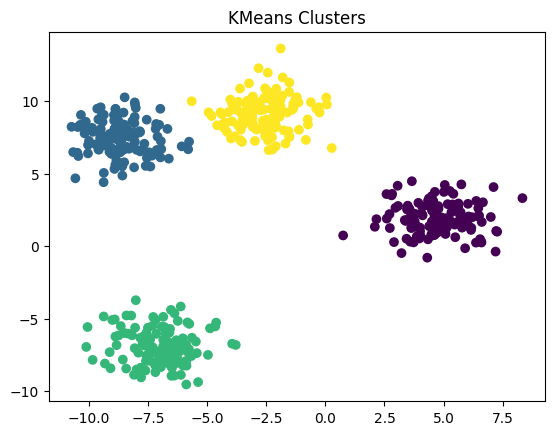

In [19]:
X, _ = make_blobs(n_samples=500, centers=4, cluster_std=1.2, random_state=42)

# KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X)

# Visualization
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.title("KMeans Clusters")
plt.show()

In [20]:
'''
Silhouette_score: 
    Kya point apne cluster me comfortable hai?

value: higher = better
Not when: dataset too big
'''
score = silhouette_score(X, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.7483022600632055


In [21]:
'''
Davis_Bouldin score: 
    Clusters ek dusre se kitne similar hain?

values: Lower = Better
Used when: we have to compare
'''
score = davies_bouldin_score(X, labels)
print("Davies Bouldin Score:", score)

Davies Bouldin Score: 0.3540970476651897


In [22]:
'''
Calinski-Harabasz Score:
    Clusters tight hain aur ek dusre se door hain?

values: Higher = better
Not when: dataset too big, 
'''
score = calinski_harabasz_score(X, labels)
print("Calinski Harabasz Score:", score)

Calinski Harabasz Score: 3997.086754976394


In [23]:
'''
Adjusted rand score: 
    How best is model clustering campared to actual clustering
    1 = best, 0 = worst
'''
ari = adjusted_rand_score(
    _,
    labels
)
print("ARI:", ari)

ARI: 1.0


In [24]:
'''
Adjusted mutual info score: 
    how much info actual and predicted cluster shares
    1 = best, 0 = worst
'''
ami = adjusted_mutual_info_score(
    _,
    labels
)
print(ami)

1.0


In [25]:
'''
Super Easy Memory : 

Imagine tumne hostel ke students ke groups banaye.

Silhouette:
Student se pooch
Tu apne group me fit hai?

Davies:
Warden se pooch:
Kya do groups bahut similar lag rahe hain?

CH:
Principal se pooch
Har group internally strong hai aur dusron se alag hai?

ARI:
Teacher se pooch
Tumhare groups mere actual groups se kitne match karte hain?

AMI:
Teacher se pooch
Tumhare groups aur mere groups kitni same information carry karte hain?
'''

'\nSuper Easy Memory : \n\nImagine tumne hostel ke students ke groups banaye.\n\nSilhouette:\nStudent se pooch\nTu apne group me fit hai?\n\nDavies:\nWarden se pooch:\nKya do groups bahut similar lag rahe hain?\n\nCH:\nPrincipal se pooch\nHar group internally strong hai aur dusron se alag hai?\n\nARI:\nTeacher se pooch\nTumhare groups mere actual groups se kitne match karte hain?\n\nAMI:\nTeacher se pooch\nTumhare groups aur mere groups kitni same information carry karte hain?\n'